<a href="https://colab.research.google.com/github/faisalkh523/Machine-Learning-Core_Tasks_KodeCamp/blob/main/CNN_training_MNIST_Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# training a CNN to recogtnize handwritten digits from the MNIST datase. MNIST contains 70000 images of handwritten digits (0-9), each 28x28 pixels in grayscale.

The CNN learns to:
1. Extract features from images using convolutional layers
2. Classify digits with fully connected layers
3. Achieve ~98-99% accuracy on the test set

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Use a GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# LeNet-5 (1998)
One of the first CNNs

Designed for digit recognition (MNIST)

**Architecture:**
- Conv → Pool → Conv → Pool → FC


In [ ]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()

    # MNIST = 28x28x1
    self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)

    # layer1 = 28x28x6
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    # pool1 = 14x14x6
    self.conv2 = nn.Conv2d(6, 16, kernel_size=3, padding=1)

    # layer2 = 14x14x6
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    # pool2 = 7x7x6
    self.fc1 = nn.Linear(16 * 7 * 7, 120)

    # FC1 = 120 flat outputs
    self.fc2 = nn.Linear(120, 10)

  def forward(self, x):
    x = torch.relu(self.conv1(x))
    x = self.pool1(x)
    x = torch.relu(self.conv2(x))
    x = self.pool2(x)
    #Flatten
    x = x.view(-1, 16 * 7 * 7)
    x = self.fc2(self.fc1(x))
    return x

Training loop

In [ ]:
batch_size = 64
learning_rate = 0.01
num_epochs = 10

## Transform (DATA PREPROCESSING AND LOADING)

### Transform: a series of operations to apply to each image

In [ ]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307), (0.3081,))
                                ])

Get the Data

In [ ]:
train_dataset = datasets.MNIST(root ='./data', train =True, download = True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 622kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.06MB/s]


In [ ]:
# DataLoader: splits dataset into batches and shuffles them
# shuffle=True: randomize order each epoch (helps prevent overfitting)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


In [ ]:
# Test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Initialize model
model = LeNet().to(device)

In [ ]:
# Training components
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Training loop
def train(model, device, train_loader, optimizer, criterion, epoch):
  # Set model to training mode.
  model.train()

  train_loss = 0
  correct = 0
  total = 0
  losses = []

  # Loop through batches
  for batch_idx, (data, target) in enumerate(train_loader):
      # data: shape of data (batch_size, 1, 28, 28)
      # target: shape of labels (batch_size,)

      # Move data to the same device as the model (GPU/CPU)
      data, target = data.to(device), target.to(device)

      # Zero the gradients
      optimizer.zero_grad()

      # Forward propagation
      pred = model(data)

      # Loss calculation
      loss = criterion(pred, target)

      # Backward propagation
      loss.backward()

      # Update weights
      optimizer.step()

      # Metrics
      train_loss += loss.item()
      losses.append(loss.item())

      # Get the predicted class (digit with highest score)
      _, predicted = pred.max(1)

      total += target.size(0)  # Add current batch size to total count
      correct += predicted.eq(target).sum().item()  # Add correct predictions to count


      # Print progress every 100 batches
      if batch_idx % 100 == 0:
          print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')


  # Calculate the average metrics
  avg_loss = train_loss / len(train_loader)
  accuracy = 100. * correct / total
  return avg_loss, accuracy, losses



In [ ]:
# Test function
def test(model, device, test_loader, criterion):
    # Switch to evaluation mode
    model.eval()

    test_loss = 0
    correct = 0
    total = 0
    losses = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            # Forward propagation
            pred = model(data)

            # Loss calculation
            loss = criterion(pred, target)

            # Metrics
            test_loss += loss.item()
            losses.append(loss.item())

            # Calculate accuracy
            _, predicted = pred.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    # Calculate average metrics
    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total

    print(f"\nTest set: Average loss: {avg_loss:.4f},"
          f"Accuracy: {correct}/{total} ({accuracy:.2f}%)\n")

    return avg_loss, accuracy, losses

In [ ]:
# Main training loop

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

train_losses_epoch_cum = []
test_losses_epoch_cum = []


for epoch in range(1, num_epochs + 1):
  train_loss, train_acc, train_losses_epoch = train(model, device, train_loader, optimizer, criterion, epoch)
  test_loss, test_acc, test_losses_epoch = test(model, device, test_loader, criterion)

  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  train_losses_epoch_cum.extend(train_losses_epoch)

  test_losses.append(test_loss)
  test_accuracies.append(test_acc)
  test_losses_epoch_cum.extend(test_losses_epoch)

print("Training complete!")
print("=" * 60)

Epoch: 1 [0/60000 (0%)]	Loss: 2.289539
Epoch: 1 [6400/60000 (11%)]	Loss: 0.181966
Epoch: 1 [12800/60000 (21%)]	Loss: 0.108596
Epoch: 1 [19200/60000 (32%)]	Loss: 0.084287
Epoch: 1 [25600/60000 (43%)]	Loss: 0.070242
Epoch: 1 [32000/60000 (53%)]	Loss: 0.143539
Epoch: 1 [38400/60000 (64%)]	Loss: 0.132963
Epoch: 1 [44800/60000 (75%)]	Loss: 0.059021
Epoch: 1 [51200/60000 (85%)]	Loss: 0.096176
Epoch: 1 [57600/60000 (96%)]	Loss: 0.012867

Test set: Average loss: 0.0934,Accuracy: 9698/10000 (96.98%)

Epoch: 2 [0/60000 (0%)]	Loss: 0.124739
Epoch: 2 [6400/60000 (11%)]	Loss: 0.189151
Epoch: 2 [12800/60000 (21%)]	Loss: 0.186950
Epoch: 2 [19200/60000 (32%)]	Loss: 0.066007
Epoch: 2 [25600/60000 (43%)]	Loss: 0.005000
Epoch: 2 [32000/60000 (53%)]	Loss: 0.035885
Epoch: 2 [38400/60000 (64%)]	Loss: 0.088435
Epoch: 2 [44800/60000 (75%)]	Loss: 0.186755
Epoch: 2 [51200/60000 (85%)]	Loss: 0.120739
Epoch: 2 [57600/60000 (96%)]	Loss: 0.070608

Test set: Average loss: 0.0979,Accuracy: 9689/10000 (96.89%)

Epoch:

Training history saved to training_history.png


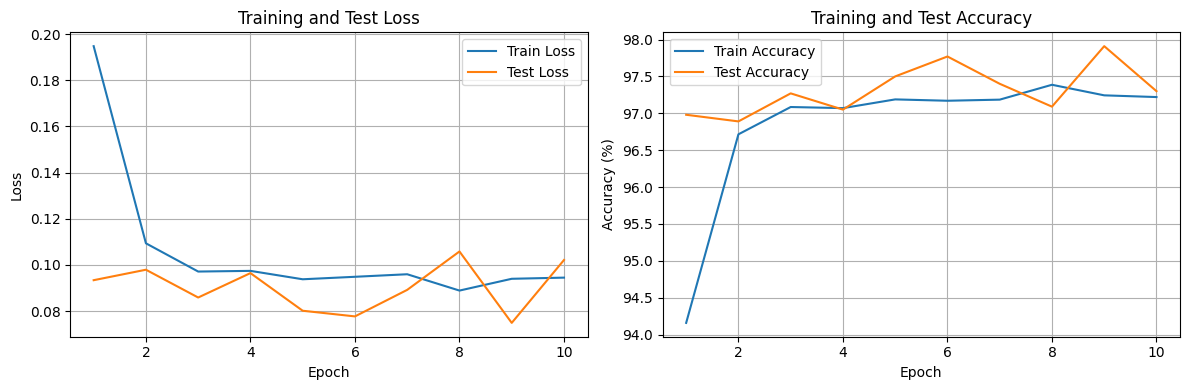

In [ ]:
# ============================================================================
# VISUALIZE TRAINING RESULTS
# ============================================================================

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# LEFT PLOT: Loss over epochs
# Loss should generally decrease over time
# If test loss starts increasing while train loss decreases, that's overfitting
ax1.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
ax1.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# RIGHT PLOT: Accuracy over epochs
# Accuracy should generally increase over time
# Large gap between train and test accuracy indicates overfitting
ax2.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
ax2.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # Adjust spacing between subplots
plt.savefig('training_history.png')  # Save the figure
print('Training history saved to training_history.png')

## **Image Visualizations**

This set of scripts visualizes the actual MNIST data and compares the trained model's predictions with the actual true values.

In [ ]:
# ============================================================================
# SAVE THE TRAINED MODEL
# ============================================================================

# Save only the model's learned parameters (weights and biases)
# To load later: model.load_state_dict(torch.load('mnist_cnn.pth'))
torch.save(model.state_dict(), 'mnist_cnn.pth')
print('Model saved to mnist_cnn.pth')
print("\nYou can now use this model to make predictions on new digit images!")

Model saved to mnist_cnn.pth

You can now use this model to make predictions on new digit images!
